Using device: cuda
Stage 1 Training: VAE (SC + ST, Marker Genes)
Configuration:
   Marker genes per type: 200
   Clustering mode: Auto-cluster (Leiden)
   Leiden resolution: 0.5
   Batch size: 256
   Epochs: 50
   Learning rate: 0.001
   Beta (KL weight): 0.1
   Hidden dims: [512, 256]
   Latent dim: 128
   Loss type: ZINB
   Lambda MMD: 1.0
Loading datasets...
   Loading SC: /home/maweicheng/ST_Graduation_Project/database/Wu/CID44971/CID44971_SC.h5ad
   SC shape: (7740, 27719)
   Loading ST: /home/maweicheng/ST_Graduation_Project/database/Wu/CID44971/CID44971_ST.h5ad
   ST shape: (1147, 23531)
   Common genes: 17323
   SC final: (7740, 17323)
   ST final: (1147, 17323)
Computing clusters and marker genes...
Starting clustering analysis...
Clustering results: 20 clusters
Marker genes per cluster:
Total: 2158 marker genes
Saved clustered SC adata: ./stage1_results/CID44971/cluster/sc_adata_clustered.h5ad
Processing SC data...
SC data (count) min: 0.0, max: 7091.33154296875
   SC data: (

VAE Training: 100%|██████████| 50/50 [00:40<00:00,  1.25epoch/s, Train=2089.9371, Recon=2081.7379, KL=81.9863, MMD=0.1418, Test=2183.5500]


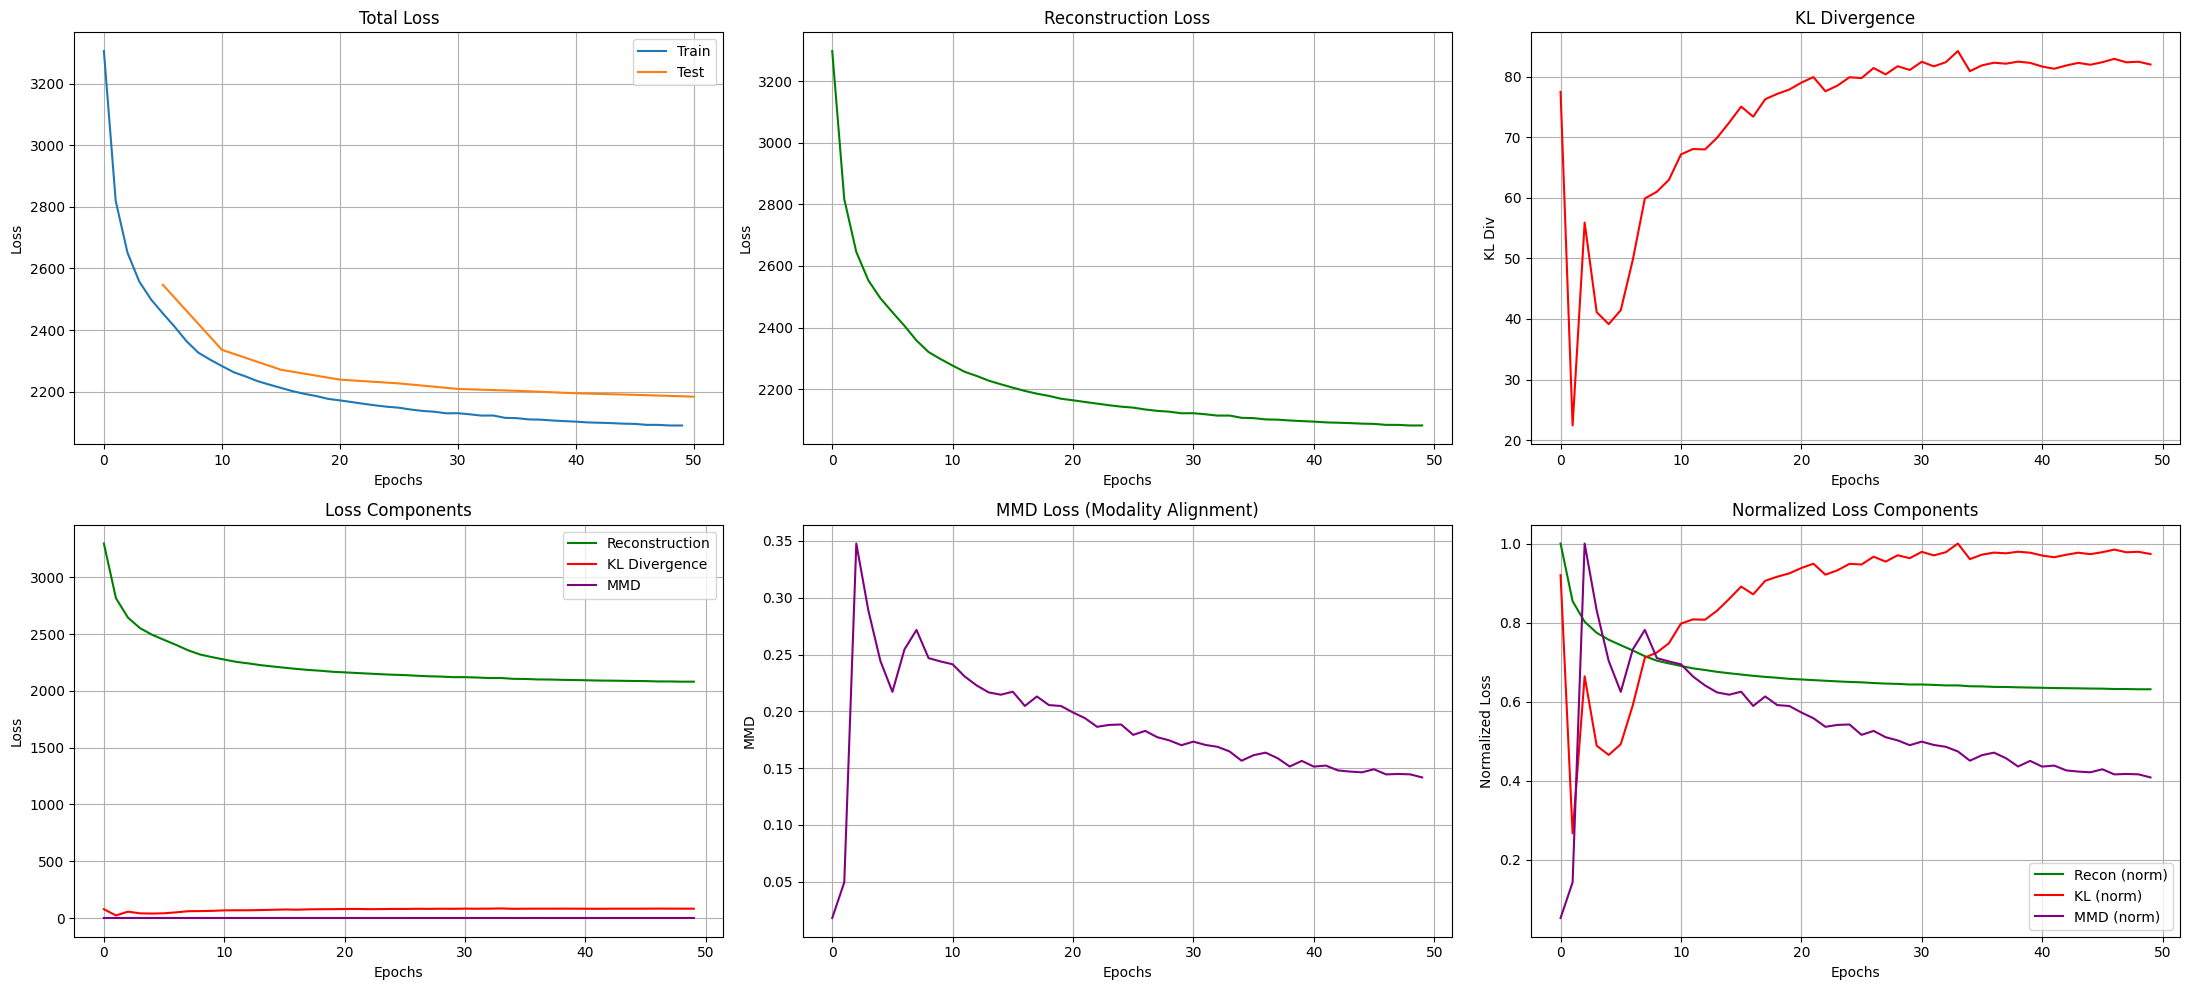

Computing cluster centers...
   SC training data: (6966, 2158)
   Number of clusters: 20
   Computing full gene cluster expressions...
      Total genes: 17323
   Completed: 20 clusters with center and expressions (all genes)
Visualizing modality alignment...
Generating UMAP visualization for modality alignment...
   Computing UMAP on 7998 samples with 128 dims...


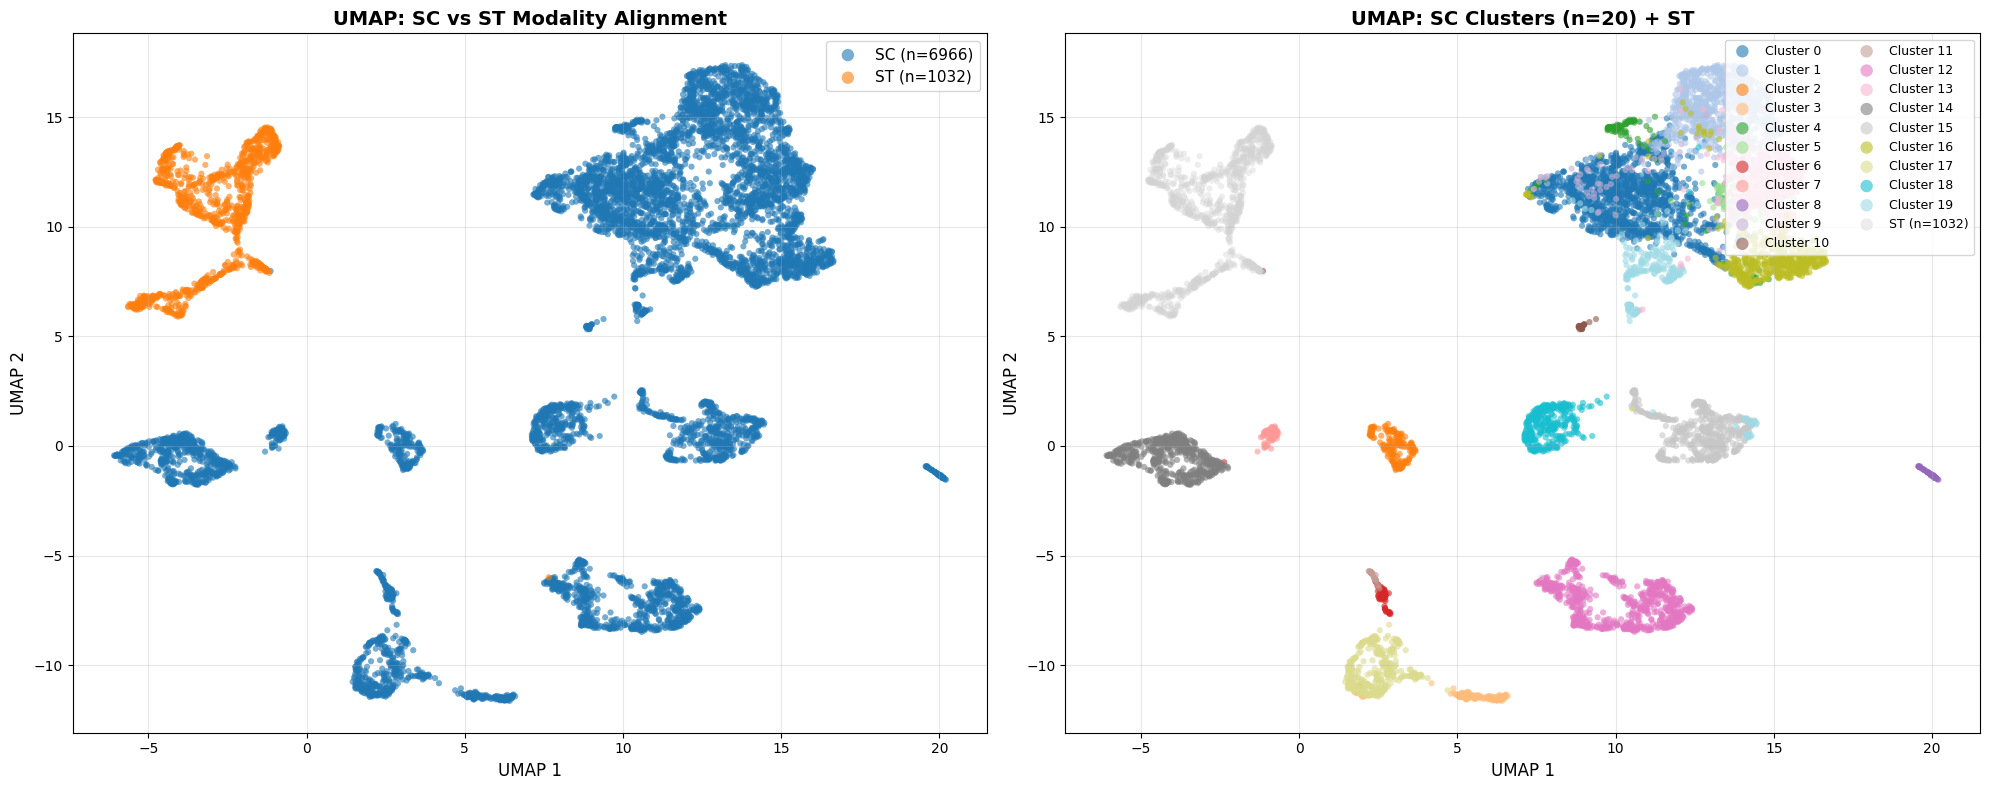

   UMAP visualization saved to: ./stage1_results/CID44971/cluster/modality_alignment_umap.png
Saving model to: ./stage1_results/CID44971/cluster/final_vae.pth
   Cluster centers: 20 clusters
   Cluster expressions (marker genes, count): 20 clusters
   Cluster expressions (all genes, count): 20 clusters
   Cluster expressions (all genes, count backup): 20 clusters


In [2]:
%run stage1.py \
    --sc_file "/home/maweicheng/ST_Graduation_Project/database/Wu/CID44971/CID44971_SC.h5ad" \
    --st_file "/home/maweicheng/ST_Graduation_Project/database/Wu/CID44971/CID44971_ST.h5ad" \
    --n_epochs 50 \
    --resolution 0.5 \
    --loss_type zinb \
    --beta 0.1 \
    --lambda_mmd 1.0 \
    --top_n_per_type 200 \
    --latent_dim 128 \
    --output_dir ./stage1_results/CID44971/cluster

---

/softwares/miniconda3/envs/dl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sample name: CID44971
Stage 1 model: ./stage1_results/CID44971/cluster/final_vae.pth
Output directory: ./stage2_results/CID44971/cluster/2025_1027_1858
Device: cuda
Loading pretrained VAE Encoder...
   VAE architecture: 2158 -> 128
   Output type: zinb
Loaded cluster centers: torch.Size([20, 128])
Loaded cluster expressions: torch.Size([20, 2158])
Loaded full gene expressions (count): 20 clusters × 17323 genes
Loaded all genes list: 17323 genes
VAE Encoder loaded: 2158 -> 128
Cell type clusters: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '3', '4', '5', '6', '7', '8', '9']
Marker genes: 2158
Using Stage 1 cluster centers and expressions...
Loaded 20 clusters
Using Stage 1 pretrained cluster data
   Cluster centers: torch.Size([20, 128])
   Cluster expressions: torch.Size([20, 2158])
Loading and processing spatial transcriptomics data...
Loading ST data: /home/maweicheng/ST_Graduation_Project/database/Wu/CID44971/CID44971_ST.h5ad
ST matching genes: 2158/2

GAT Training:  59%|█████▉    | 296/500 [09:03<06:14,  1.84s/epoch, Total=0.5353, Pearson=0.2781, Cosine=0.2558, Align=0.0009]



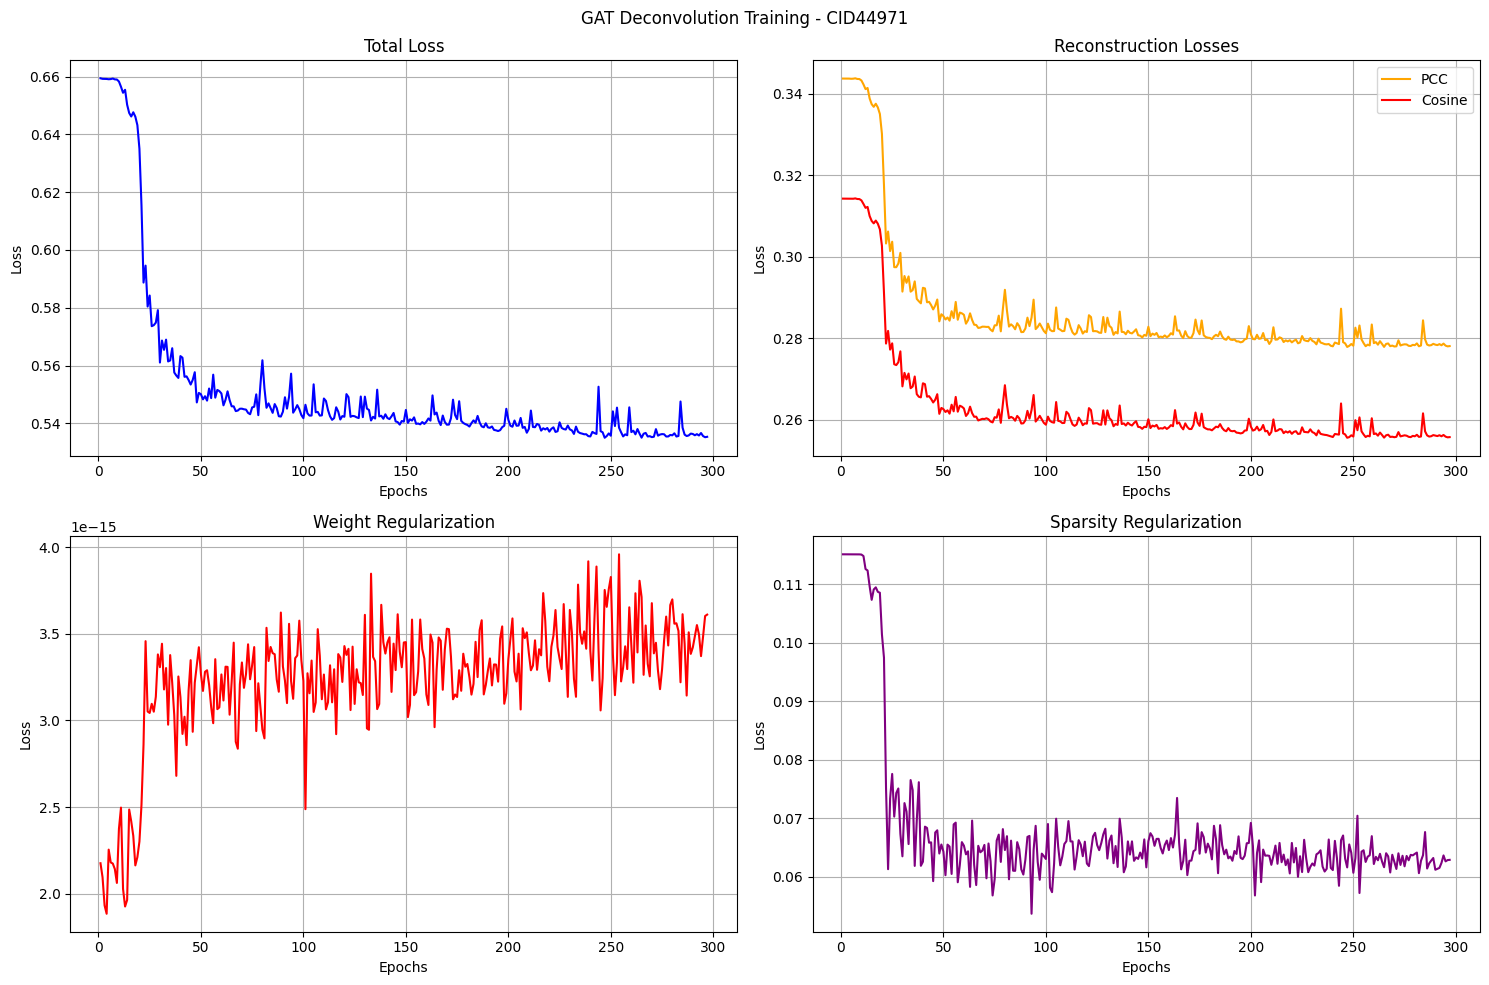

Evaluating model results...
Cells per spot: 10.0
Saving deconvolution results...
Generating deconvolution expression matrices...
   Marker gene expression...
Saving deconvolution results...
Generating deconvolution expression matrices...
   Marker gene expression...
   Full gene expression...
   Full gene expression...
   Cell type composition...
   Saved cell composition (celltype): ./stage2_results/CID44971/cluster/2025_1027_1858/CID44971_cell_composition.csv
   Cell type composition...
   Saved cell composition (celltype): ./stage2_results/CID44971/cluster/2025_1027_1858/CID44971_cell_composition.csv
   Saved cluster composition: ./stage2_results/CID44971/cluster/2025_1027_1858/CID44971_cluster_composition.csv
   Complete results saved: ./stage2_results/CID44971/cluster/2025_1027_1858/CID44971_deconvolution_results.npz
GAT deconvolution training completed!
   Saved cluster composition: ./stage2_results/CID44971/cluster/2025_1027_1858/CID44971_cluster_composition.csv
   Complete resu

In [ ]:
%run stage2.py \
    --st_file "/home/maweicheng/ST_Graduation_Project/database/Wu/CID44971/CID44971_ST.h5ad" \
    --stage1_model_path "./stage1_results/CID44971/cluster/final_vae.pth" \
    --output_dir "./stage2_results/CID44971/cluster/2025_1027_1858" \
    --gat_hidden_dim 256 \
    --gat_layers 6 \
    --lr 1e-4 \
    --loss_lambda_pearson 1.0 \
    --loss_lambda_cosine 1.0 \
    --loss_lambda_align 1.0 \
    --loss_lambda_reg 0.5 \
    --loss_lambda_sparse 0.01 \
    --k_spatial 10 \
    --k_celltype 10 \
    --batch_size 128 \
    --n_epochs 500 \
    --weight_threshold 0.01